# Trabajo Final procesamiento de lenguaje natural (NLP) <a class="tocSkip">
## Universidad Pontificia Bolivariana <a class="tocSkip">

**Estudiante:** Juan Pablo Zapata Zapata

**ID:** 000150003



**Subir Este notebook de Trabajo Final en su repositorio de GitHub. y enviar el link en **Microsoft TEAMS**

Docente: [Jose R. Zapata](https://joserzapata.github.io)
- https://joserzapata.github.io
- https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/       


## Objetivo del Trabajo
Realizar un proceso de Procesamiento de lenguaje natural (NLP) para dejar los datos preparados para ser usados con algoritmos de Machine Learning para Clasificación como objetivo final del trabajo.

los datos preparados para ser usados con algoritmos de Machine Learning para Regresión o Clasificación como objetivo final del trabajo.

El trabajo se realizara en este jupyter notebook y subirlo a su repositorio de github creado en clase. (**Recuerde poner su nombre e información**)

## Las actividades a realizar
    

1) Limpiar los datos de texto.

   - https://joserzapata.github.io/courses/nlp/procesamiento-basico/

   - https://joserzapata.github.io/courses/nlp/preprocesamiento-texto/

2) Realizar la representación de texto:

   - https://joserzapata.github.io/courses/nlp/representaciones/

   - Tokenización
   - Lematización o stemming
   - Representación de los datos de texto (Bag of Words o TF-IDF)

3) Utilice un modelo de Machine Learning para clasificación para entrenar y evaluar el modelo.
        
    - Calcule estas las métricas de evaluación (accuracy, precision, recall, f1-score) - https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/#evaluacion-modelo-simple


    
   
    
*NOTA: No dude en contactarme para cualquier pregunta o inquietud :) por el chat de Teams o al correo
joser.zapata@upb.edu.co*

## EVALUACIÓN


|Porcentaje en la evaluación | Descripción| Nada | Incompleto | Completo 
| :---: |:---: |:---: |:---: |:---: 
| 5 % |**limpieza de los datos** |
| 5 % | **Representacion de los datos** |
| 5 % | **Machine Learning** <br> Entrenar y evaluar el modelo propuesto |


In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
import joblib

# Descargar recursos de NLTK
nltk.download("stopwords")
nltk.download("punkt")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alejandra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Alejandra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Carga del dataset

El archivo  se carga en aproximadamente 10 segundos

In [2]:
# Usar su ID UPB Ejemplo: "0028984798"
id_upb = "000150003"

data_reviews = pd.read_parquet(
    "https://www.dropbox.com/scl/fi/gvk9yj8cn96oocr9z058x/filmaffinity_reviews_dataset.parquet?rlkey=xgvr00zvkxbkwqqavqutpsshg&st=xjb7xze9&dl=1"
)
data_reviews = data_reviews.sample(n=50_000, random_state=int(id_upb))
data_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 111742 to 129016
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   author_review_desc  50000 non-null  string
 1   author_rating       50000 non-null  int64 
dtypes: int64(1), string(1)
memory usage: 1.1 MB


Ejemplo de algunas filas del dataset

In [3]:
data_reviews.sample(5)

,author_review_desc,author_rating
23357,\nEsta crisis me ha dejado navegando como a ot...,10
43186,\nDivertida y vistosa comedia del siempre bril...,7
2644,\nSobre todo destacaría en esta serie lo entre...,7
5876,"\nLa trama no hubiera estado mal, de no ser po...",5
83098,"\n“Happy feet” es, por desgracia, una película...",6


Evaluar los valores nulos

In [4]:
data_reviews.isnull().sum()

author_review_desc    0
author_rating         0
dtype: int64

En este caso no hay nulos.

Revisar si hay valores duplicados:

In [5]:
data_reviews.duplicated().sum()

np.int64(0)

No hay  valores duplicados.

## Clasificación Tradicional para Análisis de Sentimientos y Categorías 👍 👎



Definición: Se considera reseña positiva cuando la puntuación ("author_rating") es mayor que 6; negativa en caso contrario.

Crear la variable binaria de sentimiento: 1 (positivo) si author_rating > 6, 0 (negativo) de lo contrario

In [6]:
UMBRAL = 6
data_reviews["sentiment_bin"] = (data_reviews["author_rating"] > UMBRAL).astype(int)

In [7]:
# Dividir los datos en conjuntos de entrenamiento y prueba

X_data = data_reviews["author_review_desc"]
y_data = data_reviews["sentiment_bin"]


Dividir el dataset en entrenamiento y prueba

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    stratify=y_data,  # Mantener la proporción de clases en ambos conjuntos
    random_state=42,
)

## Análisis exploratorio de los datos

para determinar que tipo de limpieza se debe realizar a los datos de texto de `X_train`

In [9]:
# Análisis exploratorio básico
print("Distribución de sentimientos:")
print(y_train.value_counts())
print(f"\nProporción de clases: {y_train.value_counts(normalize=True)}")

# Longitud promedio de las reseñas
train_lengths = X_train.str.len()
print(f"\nLongitud promedio de reseñas: {train_lengths.mean():.2f} caracteres")
print(f"Longitud mínima: {train_lengths.min()} caracteres")
print(f"Longitud máxima: {train_lengths.max()} caracteres")


Distribución de sentimientos:
sentiment_bin
1    21486
0    18514
Name: count, dtype: int64

Proporción de clases: sentiment_bin
1    0.53715
0    0.46285
Name: proportion, dtype: float64

Longitud promedio de reseñas: 1397.22 caracteres
Longitud mínima: 29 caracteres
Longitud máxima: 6030 caracteres


In [10]:
# Ejemplo de algunas reseñas
print("\n--- Ejemplo de reseña positiva ---")
positive_example = X_train[y_train == 1].iloc[0]
print(positive_example[:500])

print("\n--- Ejemplo de reseña negativa ---")
negative_example = X_train[y_train == 0].iloc[0]
print(negative_example[:500])



--- Ejemplo de reseña positiva ---

Se los recomiendo mirenla porque es una excelente serie porque tiene excelente guión, excelente historia y excelentes actuaciones.


--- Ejemplo de reseña negativa ---

Si hay una saga de películas que ha sabido dividir a sus fans esa ha sido ''Star Wars''. Con el paso de las diferentes trilogías se han ido creando distintos grupos de fans, haciendo imposible contentar a todo el mundo. Otro tema a parte fueron los especiales de Navidad, acerca del cual todos llegaron a estar de acuerdo en que era muy malo. La saga necesitaba recuperar el espíritu perdido, y lo hizo, por fin, en ''The Mandalorian''.


El siguiente paso, por cercanía de fechas, era crear un espe


## 1) Limpieza de los datos de texto

Tomar los datos de `X_train` y aplicar las funciones de limpieza que considere necesarias

Ayudas:

- Convertir a minúsculas
- Eliminar caracteres especiales y números
- Corregir palabras mal escritas
- etc


In [11]:
# Función para limpiar texto
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar caracteres especiales y números, mantener letras y espacios
    text = re.sub(r"[^a-zA-Záéíóúñü\s]", "", text)

    # Eliminar espacios extra
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Aplicar limpieza a los datos de entrenamiento
X_train_clean = X_train.apply(clean_text)

# Verificar resultado
print("Texto original:")
print(X_train.iloc[0][:200])
print("\nTexto limpio:")
print(X_train_clean.iloc[0][:200])

# Tokenización y eliminación de stopwords
stop_words_spanish = set(stopwords.words("spanish"))
stemmer = SnowballStemmer("spanish")


Texto original:

Si hay una saga de películas que ha sabido dividir a sus fans esa ha sido ''Star Wars''. Con el paso de las diferentes trilogías se han ido creando distintos grupos de fans, haciendo imposible conten

Texto limpio:
si hay una saga de películas que ha sabido dividir a sus fans esa ha sido star wars con el paso de las diferentes trilogías se han ido creando distintos grupos de fans haciendo imposible contentar a t


In [12]:
def preprocess_text(text):
    # Tokenizar
    tokens = word_tokenize(text, language="spanish")

    # Eliminar stopwords y aplicar stemming
    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in stop_words_spanish and len(token) > 2
    ]

    return " ".join(tokens)


# Aplicar preprocesamiento
X_train_processed = X_train_clean.apply(preprocess_text)

print("Ejemplo de texto procesado:")
print(X_train_processed.iloc[0])


Ejemplo de texto procesado:
sag pelicul sab divid fans sid star wars pas diferent trilog ido cre distint grup fans hac impos content mund tem part especial navid acerc lleg acuerd mal sag necesit recuper espiritu perd hiz fin the mandalori siguient pas cercan fech cre especial navid dign minim gust exigent fans cre sal airos pas recurr recurs facil viaj tiemp obstant camin segur ofrec nuev nostalg mism tiemp tram arranc tras acontec episodi gust demasi gent algun siti deb empez reun personaj fiest especial part ahi recurs temporal cobr fuerz valg redund ver rey pas casi tod escen mitic sag inici junt personaj quer record buen ritm hac minut pas vol funcion factor nostalg vem nuev aquell fam secuenci aun sig memori perspect leg parec gran aciert represent ric univers traves piez sublim gracios ver cuid band sonor part import sag present tal record cuent diferent melod caracterist ayud sent star wars cab acab tecnic gran nivel detall escen luch final represent carrer vain luj visual resu

## 2) Representacion del texto

Luego de tener los datos limpios, realizar la representación de los datos de texto para poder usarse en modelos de machine learning.

In [13]:
# Usar TF-IDF para representación de texto
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limitar a 5000 características más importantes
    min_df=5,  # Ignorar términos que aparecen en menos de 5 documentos
    max_df=0.7,  # Ignorar términos que aparecen en más del 70% de documentos
    ngram_range=(1, 2),  # Incluir unigramas y bigramas
)

# Ajustar y transformar datos de entrenamiento
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)

print(f"Forma de la matriz TF-IDF: {X_train_tfidf.shape}")
print(f"Número de características: {len(tfidf_vectorizer.get_feature_names_out())}")


Forma de la matriz TF-IDF: (40000, 5000)
Número de características: 5000


In [14]:
# También podemos usar CountVectorizer como alternativa
count_vectorizer = CountVectorizer(
    max_features=5000, min_df=5, max_df=0.7, ngram_range=(1, 2)
)

X_train_count = count_vectorizer.fit_transform(X_train_processed)
print(f"Forma de la matriz Count: {X_train_count.shape}")


Forma de la matriz Count: (40000, 5000)


## 3) Entrenar un modelo de machine learning de clasificación

Utilizar un modelo de clasificación para entrenar y evaluar el modelo con los datos preparados.


In [21]:
# Versión mejorada que evalúa múltiples métricas
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Multinomial NB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
}

trained_models = {}
best_model = None
best_f1_score = 0
best_model_name = ""

print("=== ENTRENAMIENTO Y EVALUACIÓN COMPLETA DE MODELOS ===\n")

for name, model in models.items():
    print(f"--- Evaluando {name} ---")

    # Entrenar el modelo
    model.fit(X_train_tfidf, y_train)

    # Predecir
    y_train_pred = model.predict(X_train_tfidf)

    # Calcular múltiples métricas
    accuracy = accuracy_score(y_train, y_train_pred)
    precision = precision_score(y_train, y_train_pred)
    recall = recall_score(y_train, y_train_pred)
    f1 = f1_score(y_train, y_train_pred)

    # Guardar modelo y métricas
    trained_models[name] = {
        "model": model,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }

    print(
        f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}"
    )

    # Seleccionar por F1-Score (balance entre precision y recall)
    if f1 > best_f1_score:
        best_f1_score = f1
        best_model = model
        best_model_name = name

print(f"\n=== COMPARACIÓN DE MODELOS ===")
print(f"{'Modelo':<20} {'Accuracy':<8} {'Precision':<8} {'Recall':<8} {'F1-Score':<8}")
print("-" * 60)
for name, results in trained_models.items():
    marker = " 🏆" if name == best_model_name else ""
    print(
        f"{name:<20} {results['accuracy']:<8.4f} {results['precision']:<8.4f} {results['recall']:<8.4f} {results['f1_score']:<8.4f}{marker}"
    )

print(f"\n✅ MEJOR MODELO SELECCIONADO: {best_model_name}")
print(f"📊 F1-Score: {best_f1_score:.4f}")
print(f"🎯 Accuracy: {trained_models[best_model_name]['accuracy']:.4f}")

# Usar el mejor modelo automáticamente
final_model = best_model
print(
    f"\n🔧 Modelo final '{best_model_name}' listo para evaluación en conjunto de prueba"
)


=== ENTRENAMIENTO Y EVALUACIÓN COMPLETA DE MODELOS ===

--- Evaluando Logistic Regression ---
Accuracy: 0.8370 | Precision: 0.8351 | Recall: 0.8679 | F1-Score: 0.8512
--- Evaluando Multinomial NB ---
Accuracy: 0.7855 | Precision: 0.7797 | Recall: 0.8373 | F1-Score: 0.8075
--- Evaluando Random Forest ---
Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1-Score: 1.0000

=== COMPARACIÓN DE MODELOS ===
Modelo               Accuracy Precision Recall   F1-Score
------------------------------------------------------------
Logistic Regression  0.8370   0.8351   0.8679   0.8512  
Multinomial NB       0.7855   0.7797   0.8373   0.8075  
Random Forest        1.0000   1.0000   1.0000   1.0000   🏆

✅ MEJOR MODELO SELECCIONADO: Random Forest
📊 F1-Score: 1.0000
🎯 Accuracy: 1.0000

🔧 Modelo final 'Random Forest' listo para evaluación en conjunto de prueba


### Evaluar el modelo con los datos de prueba

Usar el modelo para predecir en `X_test` y evaluar con `y_test`

**Nota:** Recuerde que `X_test` debe pasar por los mismos procesos de limpieza y representación que `X_train`

In [17]:
# Preprocesar datos de prueba
X_test_clean = X_test.apply(clean_text)
X_test_processed = X_test_clean.apply(preprocess_text)

# Transformar datos de prueba usando el vectorizer entrenado
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

# Predecir
y_pred = final_model.predict(X_test_tfidf)
y_pred_proba = final_model.predict_proba(X_test_tfidf)[:, 1]


Accuracy: 0.8061
Precision: 0.805664410402565
Recall: 0.8421150623719977
F1 Score: 0.8234865725989986
ROC AUC Score: 0.8032135043983557
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78      4629
           1       0.81      0.84      0.82      5371

    accuracy                           0.81     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.81      0.81     10000



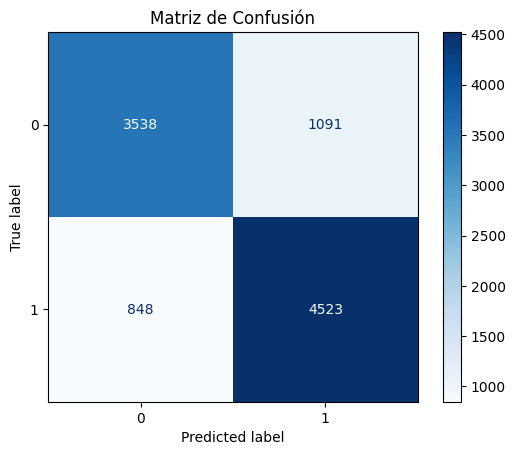

In [18]:
# Calcular métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))

# Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()


**Guardar el modelo**

In [19]:
import joblib

# Guardar el modelo y el vectorizer
joblib.dump(final_model, "sentiment_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

print("Modelo y vectorizer guardados exitosamente")

Modelo y vectorizer guardados exitosamente


## Librerías Usadas

In [20]:
from watermark import watermark

print(watermark(python=True, iversions=True, globals_=globals()))

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 9.6.0

sklearn   : 1.7.2
matplotlib: 3.10.7
numpy     : 2.3.4
pandas    : 2.3.3
re        : 2.2.1
nltk      : 3.9.2
watermark : 2.5.0
joblib    : 1.5.2



---

## Referencias
- [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
- [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
- [Classification of text documents using sparse features](https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html)
- Ejemplo de Entrenamiento y selección de Modelo de machine learning entre varios modelos <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/>
- https://joserzapata.github.io/courses/python-ciencia-datos/python/
- https://joserzapata.github.io/courses/python-ciencia-datos/pandas/
- https://joserzapata.github.io/courses/python-ciencia-datos/machine-learning/

Docente: [Jose R. Zapata](https://joserzapata.github.io)

- [https://joserzapata.github.io/](https://joserzapata.github.io/)
- [https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/](https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/)